# NOTE:
# This notebook was originally executed from:
# /content/drive/MyDrive/notebooks/
# Paths may need to be adjusted if executed from a different directory.

Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from tensorflow import keras
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.losses import MeanAbsoluteError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam


Connection to drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Getting the dataframe from the drive

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/integrated_proyecto.csv')
df.sample(10)

,Time,Front POA1 (W/m2),Front POA2 (W/m2),Rear 1 (W/m2),Rear 2 (W/m2),Rear 3 (W/m2),G,W,B,S,Temperatura C,Humedad_especifica g/kg,Precipitacion mm/hour,Humedad relativa %
47114,2022-11-04 07:15:00,45.113300,39.135500,3.076200,0.006200,1.544000,1.0,0.0,0.0,0.0,11.91,8.95,0.03,100.00
25913,2022-03-28 11:00:00,803.144400,692.293600,98.428900,89.474200,101.852900,1.0,0.0,0.0,0.0,1.06,1.91,0.02,46.99
34440,2022-06-25 06:45:00,253.524200,234.826300,69.976900,56.798900,60.957800,1.0,0.0,0.0,0.0,21.86,13.61,0.01,84.15
18825,2022-01-13 15:00:00,128.350600,127.036000,14.610800,11.675900,13.118200,0.0,1.0,0.0,0.0,3.27,3.98,0.00,83.33
92952,2024-02-24 18:45:00,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.75,3.13,0.00,78.55
84131,2023-11-24 21:30:00,0.000000,0.000000,0.000331,0.006170,0.000835,0.0,1.0,0.0,0.0,2.39,3.33,0.00,75.23
79617,2023-10-08 21:00:00,0.000000,0.000000,0.000331,0.006170,0.000835,0.0,1.0,0.0,0.0,11.25,5.97,0.00,72.01
133645,2025-04-23 16:00:00,68.623090,55.175743,13.072870,4.674065,7.716904,0.0,0.0,1.0,0.0,22.07,6.54,0.00,40.12
6501,2021-09-07 06:00:00,38.759300,32.077800,11.534900,7.008000,13.118200,0.0,1.0,0.0,0.0,17.43,11.27,0.13,91.44
134999,2025-05-07 18:30:00,18.426569,11.546318,0.000331,0.006170,0.000835,0.0,0.0,1.0,0.0,19.92,11.47,0.00,79.48


In [ ]:
df_clouds=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/era5_atmospheric_combined_2021_2025.csv')
df_clouds.sample(10)

,time,latitude,longitude,cloud_cover,cloud_liquid_water,convective_precip_mm,large_scale_precip_mm
119426,2024-11-26 00:30:00,NaN,NaN,98.911470,0.445300,0.000000,0.000932
50610,2022-12-10 04:30:00,NaN,NaN,1.842745,0.000000,0.000000,0.000000
131903,2025-04-04 23:45:00,NaN,NaN,99.801820,0.127086,0.000036,0.000000
21563,2022-02-10 14:45:00,NaN,NaN,0.000000,0.000000,0.000000,0.000000
88209,2024-01-05 20:15:00,NaN,NaN,0.000000,0.000005,0.000000,0.000000
94233,2024-03-08 14:15:00,NaN,NaN,97.995950,0.000000,0.000000,0.000000
73208,2023-08-02 14:00:00,39.65,-75.76,22.325462,0.003042,0.000000,0.000000
59266,2023-03-10 08:30:00,NaN,NaN,100.000000,0.000000,0.000000,0.000000
39009,2022-08-11 08:15:00,NaN,NaN,92.523820,0.247267,0.528930,0.029427
4232,2021-08-14 02:00:00,39.65,-75.76,100.000000,0.000005,0.000000,0.000000


Features of initial df

In [ ]:
df.shape

(135401, 14)

In [ ]:
df_clouds.shape

(137373, 7)

In [ ]:
df.dtypes

,0
Time,object
Front POA1 (W/m2),float64
Front POA2 (W/m2),float64
Rear 1 (W/m2),float64
Rear 2 (W/m2),float64
Rear 3 (W/m2),float64
G,float64
W,float64
B,float64
S,float64


Filter data

In [ ]:
df['Time']=pd.to_datetime(df['Time'],format='%Y-%m-%d %H:%M:%S')


Add missing albedo information

In [ ]:
df.iloc[129544,8]=1

Convert cloud data to datetime

In [ ]:
df_clouds['time']=pd.to_datetime(df_clouds['time'],format='%Y-%m-%d %H:%M:%S')

Adding information missing from 2025/5/23 23:00-23:45

In [ ]:
df_add=pd.DataFrame({'Time':[datetime(2025,5,11,23,0,0),datetime(2025,5,11,23,15,0),datetime(2025,5,11,23,30,0),datetime(2025,5,11,23,45,0)],
                     'Front POA1 (W/m2)':[0,0,0,0],'Front POA2 (W/m2)':[0,0,0,0],'Rear 1 (W/m2)':[0,0,0,0],'Rear 2 (W/m2)':[0,0,0,0],
                     'Rear 3 (W/m2)':[0,0,0,0],'G':[0,0,0,0],'W':[0,0,0,0],'B':[1,1,1,1],'S':[0,0,0,0],'Temperatura C':[16.49,16.49,16.49,16.49],
                     'Humedad_especifica g/kg':[10.36,10.36,10.36,10.36],'Precipitacion mm/hour':[0,0,0,0],'Humedad relativa %':[89.93,89.93,89.93,89.93]})
df=pd.concat([df,df_add],sort=False)
df

,Time,Front POA1 (W/m2),Front POA2 (W/m2),Rear 1 (W/m2),Rear 2 (W/m2),Rear 3 (W/m2),G,W,B,S,Temperatura C,Humedad_especifica g/kg,Precipitacion mm/hour,Humedad relativa %
0,2021-07-01 12:45:00,0.0,0.0,0.000000,0.00000,0.000000,0.0,0.0,0.0,0.0,31.30,14.97,6.28,52.50
1,2021-07-01 13:00:00,0.0,0.0,0.000000,0.00000,0.000000,0.0,0.0,0.0,0.0,31.41,15.40,7.38,53.62
2,2021-07-01 13:15:00,0.0,0.0,0.000000,0.00000,0.000000,0.0,0.0,0.0,0.0,31.41,15.40,7.38,53.62
3,2021-07-01 13:30:00,0.0,0.0,0.000000,0.00000,0.000000,0.0,0.0,0.0,0.0,31.41,15.40,7.38,53.62
4,2021-07-01 13:45:00,0.0,0.0,0.000000,0.00000,0.000000,0.0,0.0,0.0,0.0,31.41,15.40,7.38,53.62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135400,2025-05-11 22:45:00,0.0,0.0,0.000331,0.00617,0.000835,0.0,0.0,1.0,0.0,17.28,10.68,0.00,88.15
0,2025-05-11 23:00:00,0.0,0.0,0.000000,0.00000,0.000000,0.0,0.0,1.0,0.0,16.49,10.36,0.00,89.93
1,2025-05-11 23:15:00,0.0,0.0,0.000000,0.00000,0.000000,0.0,0.0,1.0,0.0,16.49,10.36,0.00,89.93
2,2025-05-11 23:30:00,0.0,0.0,0.000000,0.00000,0.000000,0.0,0.0,1.0,0.0,16.49,10.36,0.00,89.93


Graphs

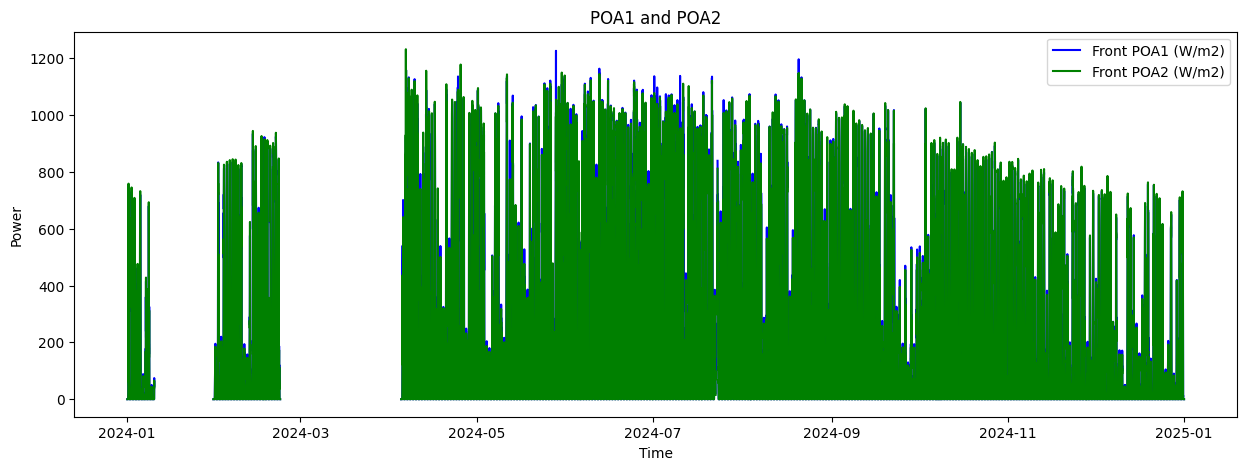

In [ ]:
dffigure=df[df.Time.dt.year==2024]
plt.figure(figsize=(15, 5))
plt.plot(dffigure['Time'],dffigure['Front POA1 (W/m2)'],label="Front POA1 (W/m2)",color='blue')
plt.plot(dffigure['Time'],dffigure['Front POA2 (W/m2)'],label="Front POA2 (W/m2)",color='green')
plt.title("POA1 and POA2")
plt.xlabel("Time")
plt.ylabel("Power")
plt.legend()
plt.show()

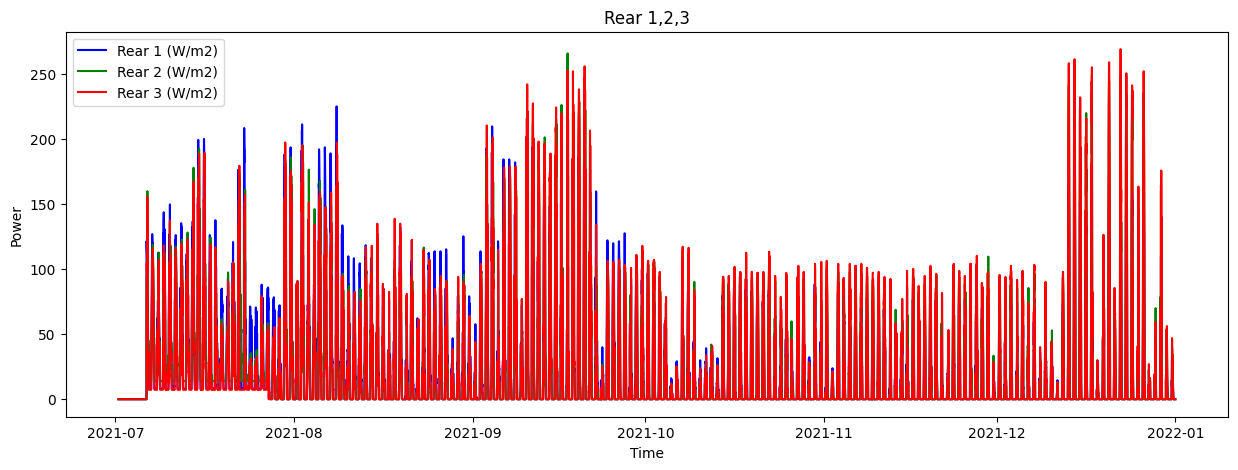

In [ ]:
dffigure2=df[df.Time.dt.year==2021]
plt.figure(figsize=(15, 5))
plt.plot(dffigure2['Time'],dffigure2['Rear 1 (W/m2)'],label="Rear 1 (W/m2)",color='blue')
plt.plot(dffigure2['Time'],dffigure2['Rear 2 (W/m2)'],label="Rear 2 (W/m2)",color='green')
plt.plot(dffigure2['Time'],dffigure2['Rear 3 (W/m2)'],label="Rear 3 (W/m2)",color='red')
plt.title("Rear 1,2,3")
plt.xlabel("Time")
plt.ylabel("Power")
plt.legend()
plt.show()

Filter null and useless values

In [ ]:
critical_date=datetime(2021,7,29,0,0,0)
df2=df[df.Time>=critical_date]
df2.head(5)

,Time,Front POA1 (W/m2),Front POA2 (W/m2),Rear 1 (W/m2),Rear 2 (W/m2),Rear 3 (W/m2),G,W,B,S,Temperatura C,Humedad_especifica g/kg,Precipitacion mm/hour,Humedad relativa %
2637,2021-07-29 00:00:00,0.0,0.0,0.0003,0.0062,0.0008,1.0,0.0,0.0,0.0,22.33,15.81,3.57,94.48
2638,2021-07-29 00:15:00,0.0,0.0,0.0003,0.0062,0.0008,1.0,0.0,0.0,0.0,22.33,15.81,3.57,94.48
2639,2021-07-29 00:30:00,0.0,0.0,0.0003,0.0062,0.0008,1.0,0.0,0.0,0.0,22.33,15.81,3.57,94.48
2640,2021-07-29 00:45:00,0.0,0.0,0.0003,0.0062,0.0008,1.0,0.0,0.0,0.0,22.33,15.81,3.57,94.48
2641,2021-07-29 01:00:00,0.0,0.0,0.0003,0.0062,0.0008,1.0,0.0,0.0,0.0,22.21,15.70,2.96,94.50


In [ ]:
critical_date2=datetime(2025,5,11,23,45,0)
df_clouds=df_clouds[df_clouds.time<=critical_date2]
df_clouds=df_clouds[df_clouds.time>=critical_date]
df_clouds

,time,latitude,longitude,cloud_cover,cloud_liquid_water,convective_precip_mm,large_scale_precip_mm
2688,2021-07-29 00:00:00,39.65,-75.76,39.964287,0.153527,0.005922,0.000048
2689,2021-07-29 00:15:00,NaN,NaN,35.300870,0.130069,0.004442,0.000036
2690,2021-07-29 00:30:00,NaN,NaN,30.637451,0.106611,0.002961,0.000024
2691,2021-07-29 00:45:00,NaN,NaN,25.974033,0.083153,0.001481,0.000012
2692,2021-07-29 01:00:00,39.65,-75.76,21.310616,0.059695,0.000000,0.000000
...,...,...,...,...,...,...,...
135451,2025-05-11 22:45:00,NaN,NaN,98.551765,0.000439,0.000000,0.000000
135452,2025-05-11 23:00:00,39.65,-75.76,99.412260,0.000063,0.000000,0.000000
135453,2025-05-11 23:15:00,NaN,NaN,99.502030,0.000048,0.000000,0.000000
135454,2025-05-11 23:30:00,NaN,NaN,99.591800,0.000033,0.000000,0.000000


In [ ]:
print(df2.shape)
print(df_clouds.shape)

(132768, 14)
(132768, 7)


Create tcc(total cloud cover) in our data frame

In [ ]:
df2['tcc']=df_clouds['cloud_cover'].values
df2['tclw']=df_clouds['cloud_liquid_water'].values

df2.sample(5)

/tmp/ipython-input-715448425.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['tcc']=df_clouds['cloud_cover'].values
/tmp/ipython-input-715448425.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['tclw']=df_clouds['cloud_liquid_water'].values


,Time,Front POA1 (W/m2),Front POA2 (W/m2),Rear 1 (W/m2),Rear 2 (W/m2),Rear 3 (W/m2),G,W,B,S,Temperatura C,Humedad_especifica g/kg,Precipitacion mm/hour,Humedad relativa %,tcc,tclw
23710,2022-03-05 12:15:00,838.72670,789.81820,83.818400,102.699900,111.112200,1.0,0.0,0.0,0.0,7.44,3.71,0.00,59.23,100.000000,0.000000
73552,2023-08-06 16:45:00,137.88159,106.50447,24.607466,24.123627,21.605827,0.0,1.0,0.0,0.0,30.57,12.12,0.60,44.53,35.702225,0.043669
93360,2024-02-29 00:45:00,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,1.70,2.71,0.00,63.84,100.000000,0.171498
119485,2024-11-27 04:00:00,0.00000,0.00000,0.000331,0.006170,0.000835,0.0,0.0,1.0,0.0,2.29,4.05,0.00,91.38,5.409553,0.000000
120264,2024-12-05 06:45:00,0.00000,0.00000,0.000331,0.006170,0.000835,0.0,0.0,1.0,0.0,3.06,3.76,1.35,79.05,16.497830,0.023036


Sin and cosine for every hour and day of the year

In [ ]:
df2['sin_h']=np.sin(2*np.pi*df2['Time'].dt.hour/24)
df2['cos_h']=np.cos(2*np.pi*df2['Time'].dt.hour/24)

df2['sin_doy']=np.sin(2*np.pi*df2['Time'].dt.dayofyear/365)
df2['cos_doy']=np.cos(2*np.pi*df2['Time'].dt.dayofyear/365)

df2.sample(5)

/tmp/ipython-input-3108037030.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['sin_h']=np.sin(2*np.pi*df2['Time'].dt.hour/24)
/tmp/ipython-input-3108037030.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['cos_h']=np.cos(2*np.pi*df2['Time'].dt.hour/24)
/tmp/ipython-input-3108037030.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata

,Time,Front POA1 (W/m2),Front POA2 (W/m2),Rear 1 (W/m2),Rear 2 (W/m2),Rear 3 (W/m2),G,W,B,S,Temperatura C,Humedad_especifica g/kg,Precipitacion mm/hour,Humedad relativa %,tcc,tclw,sin_h,cos_h,sin_doy,cos_doy
84461,2023-11-28 08:00:00,135.33998,117.41182,35.373080,24.123627,38.581177,0.0,1.0,0.0,0.0,1.58,3.17,0.00,74.97,42.15928,0.000015,0.866025,-5.000000e-01,-0.538005,0.842942
82774,2023-11-10 18:15:00,0.00000,0.00000,0.000331,0.006170,0.000835,0.0,1.0,0.0,0.0,5.70,5.24,0.00,93.38,100.00000,0.198779,-1.000000,-1.836970e-16,-0.769415,0.638749
87328,2023-12-28 04:45:00,0.00000,0.00000,0.000331,0.006170,0.000835,0.0,1.0,0.0,0.0,8.54,6.78,3.97,97.63,100.00000,0.243369,0.866025,5.000000e-01,-0.051620,0.998667
28429,2022-04-23 16:00:00,145.50640,151.41710,29.221300,22.567700,22.377400,1.0,0.0,0.0,0.0,19.49,8.19,0.25,58.92,76.29231,0.017299,-0.866025,-5.000000e-01,0.930724,-0.365723
54832,2023-01-23 16:45:00,3.81240,0.00000,0.000300,0.006200,0.000800,1.0,0.0,0.0,0.0,4.43,4.12,0.88,79.37,97.52474,0.051983,-0.866025,-5.000000e-01,0.385663,0.922640


Filter null values

In [ ]:
col_time=df2['Time']
counter=0
dates_null=[]
for elemento in col_time:
  if pd.isna(df2.iloc[counter,1])==True or pd.isna(df2.iloc[counter,2])==True or pd.isna(df2.iloc[counter,3])==True or pd.isna(df2.iloc[counter,4])==True or pd.isna(df2.iloc[counter,5])==True:
    dates_null.append(datetime(elemento.year,elemento.month,elemento.day))
  counter+=1
set_dates_null=set(dates_null)
print(set_dates_null)





{datetime.datetime(2022, 6, 10, 0, 0), datetime.datetime(2024, 2, 29, 0, 0), datetime.datetime(2024, 1, 16, 0, 0), datetime.datetime(2024, 3, 25, 0, 0), datetime.datetime(2021, 11, 9, 0, 0), datetime.datetime(2024, 1, 29, 0, 0), datetime.datetime(2024, 2, 25, 0, 0), datetime.datetime(2024, 3, 27, 0, 0), datetime.datetime(2024, 1, 15, 0, 0), datetime.datetime(2024, 3, 2, 0, 0), datetime.datetime(2024, 3, 19, 0, 0), datetime.datetime(2024, 3, 15, 0, 0), datetime.datetime(2024, 3, 20, 0, 0), datetime.datetime(2024, 3, 30, 0, 0), datetime.datetime(2024, 2, 23, 0, 0), datetime.datetime(2024, 1, 18, 0, 0), datetime.datetime(2024, 1, 22, 0, 0), datetime.datetime(2024, 3, 22, 0, 0), datetime.datetime(2024, 7, 23, 0, 0), datetime.datetime(2024, 2, 24, 0, 0), datetime.datetime(2024, 3, 10, 0, 0), datetime.datetime(2024, 4, 1, 0, 0), datetime.datetime(2024, 1, 24, 0, 0), datetime.datetime(2024, 1, 25, 0, 0), datetime.datetime(2024, 3, 6, 0, 0), datetime.datetime(2024, 1, 23, 0, 0), datetime.datet

In [ ]:
df3=df2
for date in set_dates_null:
  df3=df3[~((df3.Time.dt.year == date.year) &(df3.Time.dt.month == date.month) &(df3.Time.dt.day == date.day))]

df3.shape

(125664, 20)

In [ ]:
df3

,Time,Front POA1 (W/m2),Front POA2 (W/m2),Rear 1 (W/m2),Rear 2 (W/m2),Rear 3 (W/m2),G,W,B,S,Temperatura C,Humedad_especifica g/kg,Precipitacion mm/hour,Humedad relativa %,tcc,tclw,sin_h,cos_h,sin_doy,cos_doy
2637,2021-07-29 00:00:00,0.0,0.0,0.000300,0.00620,0.000800,1.0,0.0,0.0,0.0,22.33,15.81,3.57,94.48,39.964287,0.153527,0.000000,1.000000,-0.455907,-0.890028
2638,2021-07-29 00:15:00,0.0,0.0,0.000300,0.00620,0.000800,1.0,0.0,0.0,0.0,22.33,15.81,3.57,94.48,35.300870,0.130069,0.000000,1.000000,-0.455907,-0.890028
2639,2021-07-29 00:30:00,0.0,0.0,0.000300,0.00620,0.000800,1.0,0.0,0.0,0.0,22.33,15.81,3.57,94.48,30.637451,0.106611,0.000000,1.000000,-0.455907,-0.890028
2640,2021-07-29 00:45:00,0.0,0.0,0.000300,0.00620,0.000800,1.0,0.0,0.0,0.0,22.33,15.81,3.57,94.48,25.974033,0.083153,0.000000,1.000000,-0.455907,-0.890028
2641,2021-07-29 01:00:00,0.0,0.0,0.000300,0.00620,0.000800,1.0,0.0,0.0,0.0,22.21,15.70,2.96,94.50,21.310616,0.059695,0.258819,0.965926,-0.455907,-0.890028
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135400,2025-05-11 22:45:00,0.0,0.0,0.000331,0.00617,0.000835,0.0,0.0,1.0,0.0,17.28,10.68,0.00,88.15,98.551765,0.000439,-0.500000,0.866025,0.774884,-0.632103
0,2025-05-11 23:00:00,0.0,0.0,0.000000,0.00000,0.000000,0.0,0.0,1.0,0.0,16.49,10.36,0.00,89.93,99.412260,0.000063,-0.258819,0.965926,0.774884,-0.632103
1,2025-05-11 23:15:00,0.0,0.0,0.000000,0.00000,0.000000,0.0,0.0,1.0,0.0,16.49,10.36,0.00,89.93,99.502030,0.000048,-0.258819,0.965926,0.774884,-0.632103
2,2025-05-11 23:30:00,0.0,0.0,0.000000,0.00000,0.000000,0.0,0.0,1.0,0.0,16.49,10.36,0.00,89.93,99.591800,0.000033,-0.258819,0.965926,0.774884,-0.632103


Divide by ground/albedo

In [ ]:
df3G=df3[df3.G==1]
df3W=df3[df3.W==1]
df3B=df3[df3.B==1]
df3S=df3[df3.S==1]
print(df3G.shape)
print(df3W.shape)
print(df3B.shape)
print(df3S.shape)

(47232, 20)
(47040, 20)
(29376, 20)
(2016, 20)


Divide by year

In [ ]:
df_2021=df3[df3.Time.dt.year==2021]
print(df_2021.shape)
df_2022=df3[df3.Time.dt.year==2022]
print(df_2022.shape)
df_2023=df3[df3.Time.dt.year==2023]
print(df_2023.shape)
df_2024=df3[df3.Time.dt.year==2024]
print(df_2024.shape)
df_2025=df3[df3.Time.dt.year==2025]
print(df_2025.shape)


(14880, 20)
(34848, 20)
(34848, 20)
(28512, 20)
(12576, 20)


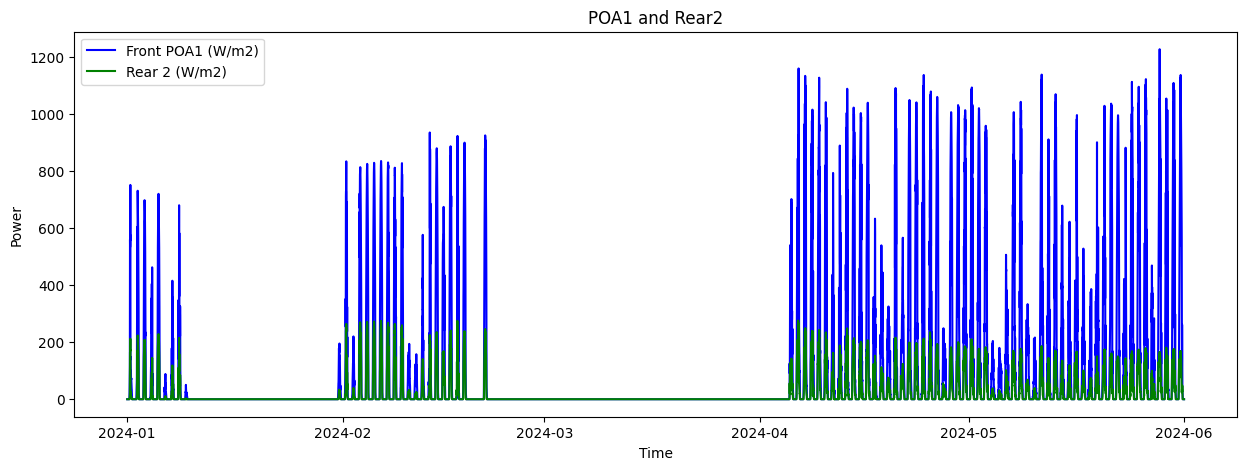

In [ ]:
dffigure=df3[(df3.Time.dt.year==2024)&(df3.Time.dt.month<=5)]
plt.figure(figsize=(15, 5))
plt.plot(dffigure['Time'],dffigure['Front POA1 (W/m2)'],label="Front POA1 (W/m2)",color='blue')
plt.plot(dffigure['Time'],dffigure['Rear 2 (W/m2)'],label="Rear 2 (W/m2)",color='green')
plt.title("POA1 and Rear2")
plt.xlabel("Time")
plt.ylabel("Power")
plt.legend()
plt.show()

In [ ]:
df2.shape


(132768, 20)

In [ ]:
df3.shape

(125664, 20)

Time gaps

In [ ]:
df2_time=df2['Time']
df3_time=df3['Time']
i_s=0
index_i=[]
for m in range(0,132768,96):
  if df2_time.iloc[m]==df3_time.iloc[i_s]:
    i_s+=96
  else:
    index_i.append(i_s)

set_i=list(set(index_i))
print(set_i)

#Here we are trying to find where are the time gaps,
#so we check that for every day


[9888, 28416, 67584, 70272, 30144, 85440, 87264, 87360, 97728, 105888]


In [ ]:
df3_time.iloc[87360]

Timestamp('2024-04-05 00:00:00')

Save the dataset

In [ ]:
df3.to_csv('/content/drive/MyDrive/Colab Notebooks/df3.csv',index=False)

Correlation

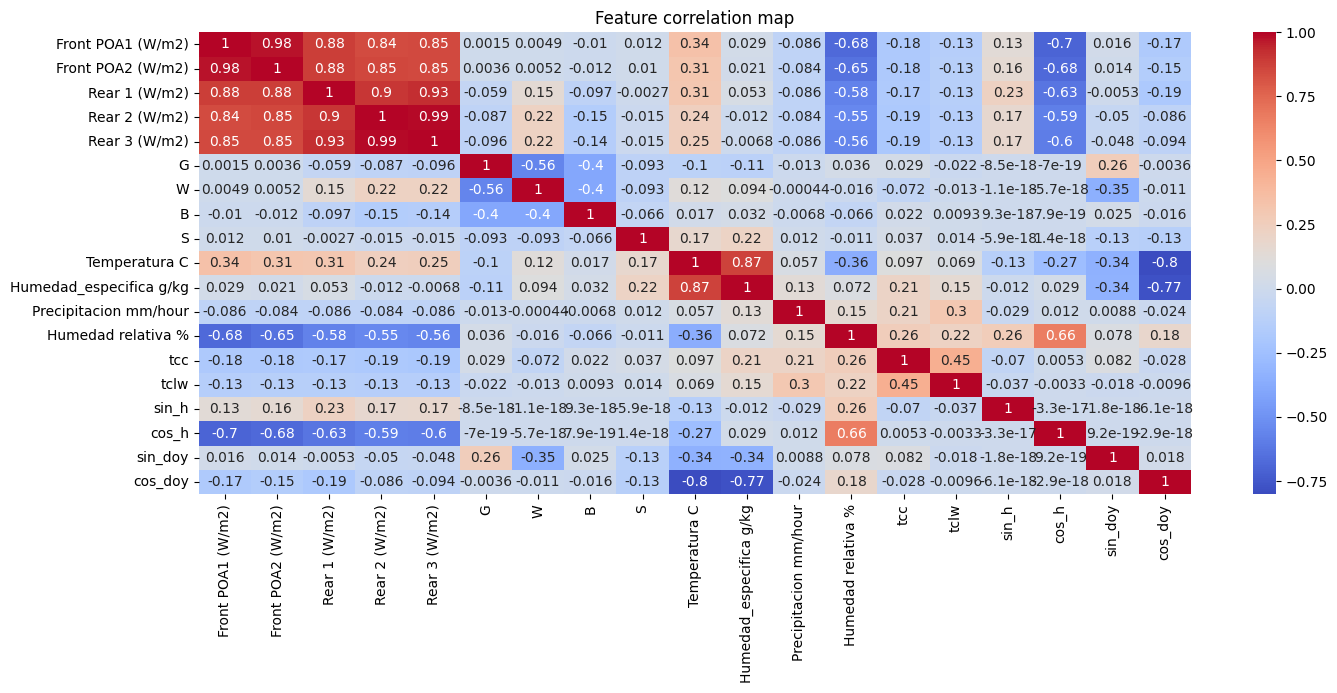

In [ ]:
data_corr=df2.select_dtypes(include=["float64"])
plt.figure(figsize=(16,6))
sns.heatmap(data_corr.corr(),annot=True,cmap="coolwarm")
plt.title("Feature correlation map")
plt.show()

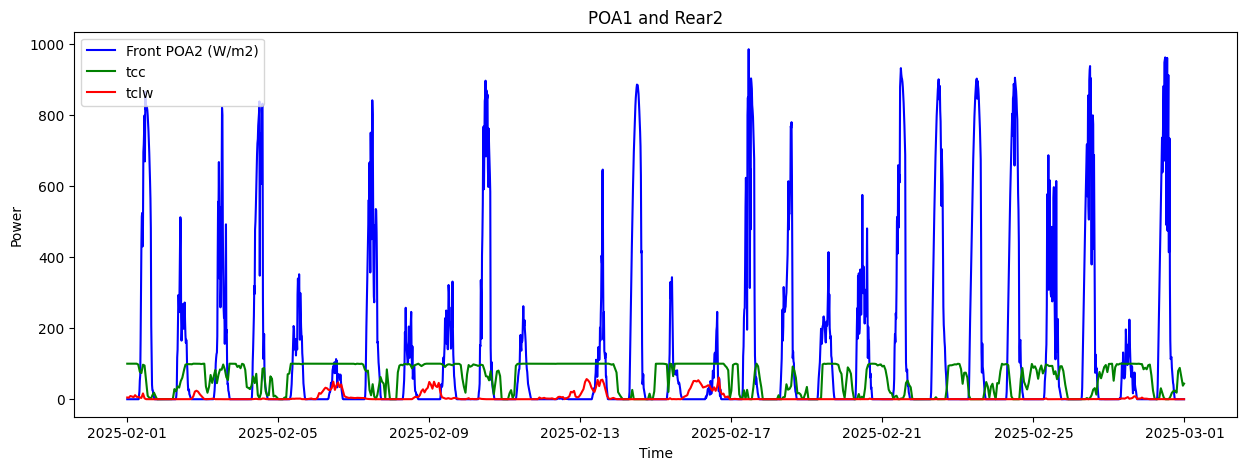

In [ ]:
dffigure=df3[(df3.Time.dt.year==2025)&(df3.Time.dt.month==2)]
plt.figure(figsize=(15, 5))
plt.plot(dffigure['Time'],dffigure['Front POA2 (W/m2)'],label="Front POA2 (W/m2)",color='blue')
plt.plot(dffigure['Time'],dffigure['tcc'],label="tcc",color='green')
plt.plot(dffigure['Time'],dffigure['tclw']*50,label="tclw",color='red')
plt.title("POA1 and Rear2")
plt.xlabel("Time")
plt.ylabel("Power")
plt.legend()
plt.show()